## Assignment 4

In this assignment, you will work with a sample of 10,000 posts on Bluesky, a social media platform. The dataset is available at this link: https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

As you can see, the original dataset contains 2 million posts, but we'll take a random sample of 10,000 to make things easier to deal with. (And even when doing work on large datasets, it's a good idea to first implement everything on a smaller sample).

Please do the following as the initial steps:

**0)** Create a HuggingFace account, get a token, and add the token to Google Colab. This week's module in Canvas describes in detail how to do that. This will allow you to use language models from HuggingFace.

**1)** Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU" and click on "Save." This is a freely available GPU and should speed things up considerably.

**2)** Run the code chunk below to load the dataset. This will create a pandas dataframe called `df`, which has 10,000 rows and every row corresponds to a single post from Bluesky.


In [1]:
%%capture
!pip install datasets
from datasets import load_dataset
import pandas as pd
ds = load_dataset("alpindale/two-million-bluesky-posts")
ds_train = ds['train']
sampled_ds = ds_train.shuffle(seed=42).select(range(10000))
df = sampled_ds.to_pandas()

### Question 1

The first task is to detect the language associated with each post. Use the following language detection model to detect the language of each post using its text (the "text" column in `df`): https://huggingface.co/papluca/xlm-roberta-base-language-detection

The page describes how to use the model, including using the pipeline() functionality of transformers (Where it says "The easiest way to use the model is via the high-level pipeline API:").

Please add code or text chunks below as needed to do the following tasks and answer the questions. You can take the model's findings at face value (if it says a post is in German but it's actually in English, you do not need to correct it.)

**A. (2 points)** How many posts, out of the 10,000 total, are in English?

**B. (2 points)** Create a barchart using seaborn that shows the top 10 most frequent languages. Put the languages on the x-axis and the number of associated with each post on the y-axis.

**C. (2 points)** Filter out the posts that are not in English by creating `df_english`, which only contains the rows in `df` that are English.

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
from tqdm import tqdm

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [5]:
# A ->
lang_model = pipeline("text-classification", model="papluca/xlm-roberta-base-language-detection")

tqdm.pandas()
df["language"] = df["text"].progress_apply(lambda x: lang_model(x)[0]['label'])

english_count = df[df["language"] == "en"].shape[0]
print(f"\nNumber of English posts: {english_count}")

Device set to use cuda:0
100%|██████████| 10000/10000 [01:38<00:00, 101.80it/s]


Number of English posts: 5059


<ipython-input-6-0121523a512d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_languages.index, y=top_languages.values, palette="viridis")


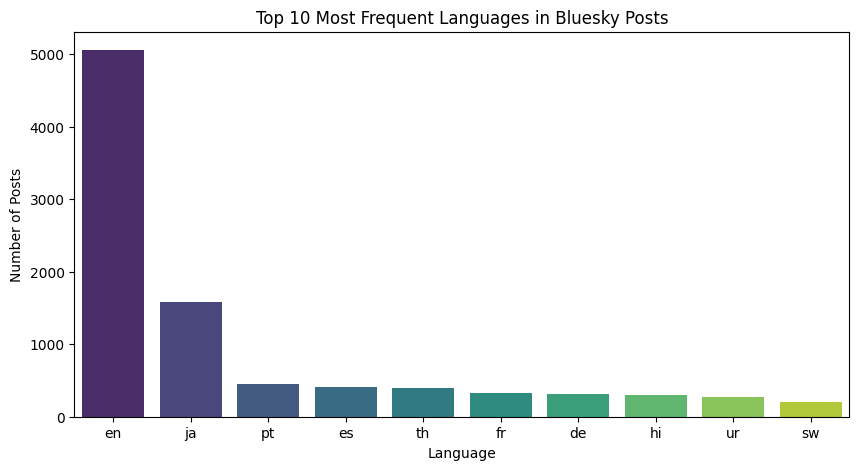

In [6]:
# B ->
top_languages = df["language"].value_counts().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_languages.index, y=top_languages.values, palette="viridis")
plt.xlabel("Language")
plt.ylabel("Number of Posts")
plt.title("Top 10 Most Frequent Languages in Bluesky Posts")
plt.show()

In [9]:
# C ->

df_english = df[df["language"] == "en"].copy()
total_posts = len(df)
total_english_posts = len(df_english)
total_non_english_posts = total_posts - total_english_posts

print(f"Total number of non-English posts: {total_non_english_posts}")

Total number of non-English posts: 4941


### Question 2

Complete this question using `df_english`.

Use the following model for sentiment detection: https://huggingface.co/siebert/sentiment-roberta-large-english

Even though the exmaple given in the page is for a single string ("I love this!"), it should work when supplied with a list of strings too (which will be faster than doing every post one-by-one, say, in a for loop)

Please add code or text chunks as needed below to do the following tasks and answer the questions. You can take the model's findings at face value (if it says a post is positive, then just assume it is positive---and same for negative.)

**A. (2 points)** What percentage of posts in `df_english` are positive? What percentage are negative?

**B. (2 points)** Some of the posts are in reply to other posts while others are standalone posts. One can tell this using the `reply_to` column. If `reply_to` is None, that means it's a standalone post. Otherwise, it is in reply to another post. What percentage of posts that are reply to other posts is positive? What percentage of standalone posts are positive? Which of the two categories have a higher percentage of positive posts?


In [12]:
sentiment_model = pipeline("sentiment-analysis", model="siebert/sentiment-roberta-large-english")

df_english["sentiment"] = df_english["text"].progress_apply(lambda x: sentiment_model(x)[0]['label'])

positive_percentage = (df_english["sentiment"] == "POSITIVE").mean() * 100
negative_percentage = (df_english["sentiment"] == "NEGATIVE").mean() * 100

print(f"\nPercentage of positive posts: {positive_percentage:.2f}%")
print(f"\nPercentage of negative posts: {negative_percentage:.2f}%")

Device set to use cuda:0
100%|██████████| 5059/5059 [01:30<00:00, 55.86it/s]


Percentage of positive posts: 60.84%

Percentage of negative posts: 39.16%


In [13]:
df_english["is_reply"] = df_english["reply_to"].notna()

positive_replies = (df_english[df_english["is_reply"]]["sentiment"] == "POSITIVE").mean() * 100
positive_standalone = (df_english[~df_english["is_reply"]]["sentiment"] == "POSITIVE").mean() * 100

print(f"\nPercentage of positive replies: {positive_replies:.2f}%")
print(f"Percentage of positive standalone posts: {positive_standalone:.2f}%")

higher_category = "Replies" if positive_replies > positive_standalone else "Standalone posts"
print(f"\nThe category with a higher percentage of positive posts is: {higher_category}")


Percentage of positive replies: 57.50%
Percentage of positive standalone posts: 64.60%

The category with a higher percentage of positive posts is: Standalone posts
